In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.widgets import Slider

In [2]:
#Equations of Motion
def mond_orbit_equations(t, y, G, M, a0):
    """
    y = [x, y, vx, vy]
    Returns derivatives [vx, vy, ax, ay]
    """
    x, y_pos, vx, vy = y
    r = np.sqrt(x**2 + y_pos**2)
    
    # Avoid division by zero
    if r < 1e-5:
        return [0, 0, 0, 0]
    
    # Newtonian acceleration magnitude
    a_N = (G * M) / r**2
    
    # MOND Modification (Simple Interpolation Function)
    # As a0 -> 0, factor -> 1 (Pure Newtonian Keplerian Orbit)
    # As a0 increases, MOND effects kick in, changing the force law and causing precession
#     factor = np.sqrt(0.5 + 0.5 * np.sqrt(1 + 4 * (a0 / a_N)**2))
#     a_MOND = a_N * factor
    a_MOND = (a_N + np.sqrt(a_N**2 + 4*a_N*a0))/2
    # Components of acceleration
    ax = -a_MOND * (x / r)
    ay = -a_MOND * (y_pos / r)
    
    return [vx, vy, ax, ay]

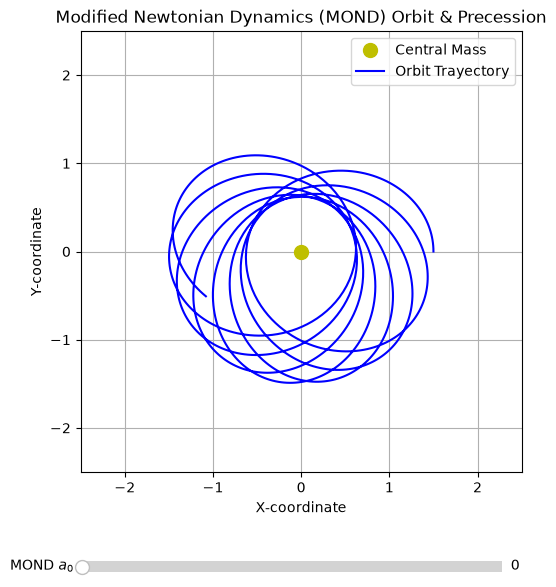

In [6]:
#Simulation Parameters & Initial Conditions
G = 1.0
M = 1.0
t_span = (0, 50)  # Time span for the orbit
t_eval = np.linspace(0, 50, 1000) # Smooth plotting points

# Initial state: [x0, y0, vx0, vy0]
initial_state = [1.5, 0.0, 0.0, 0.65]

#Interactive Plot Setup
fig, ax = plt.subplots(figsize=(7, 7))
plt.subplots_adjust(bottom=0.25) # Leave room for the slider

#Run initial Newtonian simulation (a0 = 0)
sol_initial = solve_ivp(mond_orbit_equations, t_span, initial_state, 
                        args=(G, M, 0.1), t_eval=t_eval, rtol=1e-9, atol=1e-9)

# Plot central mass and initial orbit
mass_dot = ax.plot(0, 0, 'yo', markersize=10, label='Central Mass')[0]
orbit_line, = ax.plot(sol_initial.y[0], sol_initial.y[1], 'b-', label='Orbit Trayectory')

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.set_title("Modified Newtonian Dynamics (MOND) Orbit & Precession")
ax.set_xlabel("X-coordinate")
ax.set_ylabel("Y-coordinate")
ax.grid(True)
ax.legend()

# 4. Add Interactive Slider for a0
ax_a0 = plt.axes([0.2, 0.1, 0.6, 0.03]) # [left, bottom, width, height]
slider_a0 = Slider(ax_a0, 'MOND $a_0$', 0.0, 2.0, valinit=0.0, valstep=0.05)

# 5. Update Function for the Slider
def update(val):
    current_a0 = slider_a0.val
    
    # Re-solve differential equations with new a0
    sol = solve_ivp(mond_orbit_equations, t_span, initial_state, 
                    args=(G, M, current_a0), t_eval=t_eval, rtol=1e-9, atol=1e-9)
    
    # Update plot line data
    orbit_line.set_data(sol.y[0], sol.y[1])
    
    # Dynamically scale axis if the orbit gets too large
    max_r = max(np.max(np.abs(sol.y[0])), np.max(np.abs(sol.y[1])), 2.0)
    ax.set_xlim(-max_r - 0.5, max_r + 0.5)
    ax.set_ylim(-max_r - 0.5, max_r + 0.5)
    
    fig.canvas.draw_idle()

# Register the update function with the slider
slider_a0.on_changed(update)

plt.show()